In [7]:
!pip uninstall -y tensorflow keras keras-nightly keras-preprocessing keras-vis

Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Successfully uninstalled tensorflow-2.16.2
Found existing installation: keras 3.1.1
Uninstalling keras-3.1.1:
  Successfully uninstalled keras-3.1.1


In [10]:
!pyenv install 3.9.18
!pyenv virtualenv 3.9.18 falcon-tf
!pyenv activate falcon-tf

/bin/bash: line 1: pyenv: command not found
/bin/bash: line 1: pyenv: command not found
/bin/bash: line 1: pyenv: command not found


In [3]:
from google.colab import drive
drive.mount('/users/')

Drive already mounted at /users/ to attempt to forcibly remount, call drive.mount("/users/", force_remount=True).


In [5]:
import tensorflow as tf
import keras

keras.config.enable_unsafe_deserialization()
print(tf.__version__, keras.__version__)

2.16.2 3.1.1


In [6]:
model_path = "/users/"

model = tf.keras.models.load_model(model_path, compile=False)
print("Model loaded successfully!")


ValueError: Could not interpret initializer identifier: {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None, 'shared_object_id': 137821221972560}

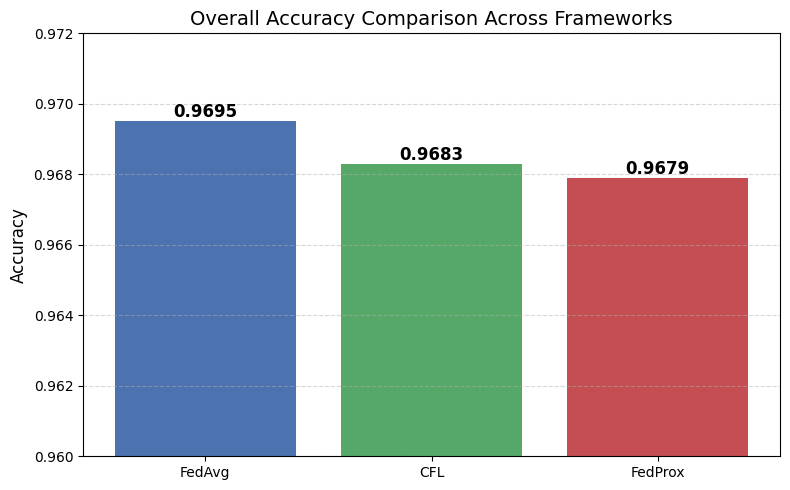

Saved: overall_accuracy_comparison.png and .pdf


In [1]:
import matplotlib.pyplot as plt

# -----------------------------
# Accuracy Values
# -----------------------------
frameworks = ["FedAvg", "CFL", "FedProx"]
accuracies = [0.9695, 0.9683, 0.9679]

# -----------------------------
# Plot Configuration
# -----------------------------
plt.figure(figsize=(8, 5))
bars = plt.bar(frameworks, accuracies, color=["#4C72B0", "#55A868", "#C44E52"])

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{acc:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.ylim(0.96, 0.972)  # Zoom into accuracy range for clearer comparison
plt.title("Overall Accuracy Comparison Across Frameworks", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# -----------------------------
# Save the figure
# -----------------------------
plt.tight_layout()
plt.savefig("overall_accuracy_comparison.png", dpi=400)
plt.savefig("overall_accuracy_comparison.pdf")  # optional high-quality PDF
plt.show()

print("Saved: overall_accuracy_comparison.png and .pdf")


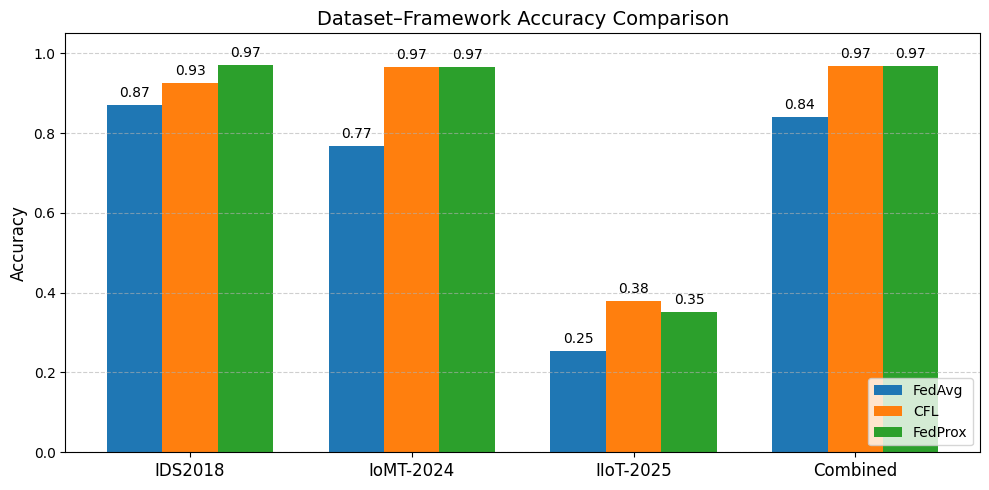

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Dataset-wise accuracy values (12 rows)
# -----------------------------------------
datasets = ["IDS2018", "IoMT-2024", "IIoT-2025", "Combined"]

fedavg = [0.8694, 0.7677, 0.2531, 0.8402]
cfl     = [0.9253, 0.9659, 0.3802, 0.9675]
fedprox = [0.9702, 0.9664, 0.3516, 0.9679]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(10, 5))

# Bars for each framework
plt.bar(x - width, fedavg, width, label='FedAvg')
plt.bar(x,         cfl,     width, label='CFL')
plt.bar(x + width, fedprox, width, label='FedProx')

plt.xticks(x, datasets, fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Dataset–Framework Accuracy Comparison", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add labels above bars
for i, (fa, c, fp) in enumerate(zip(fedavg, cfl, fedprox)):
    plt.text(i - width, fa + 0.02, f"{fa:.2f}", ha="center")
    plt.text(i,         c  + 0.02, f"{c:.2f}", ha="center")
    plt.text(i + width, fp + 0.02, f"{fp:.2f}", ha="center")

# Legend moved to bottom-right
plt.legend(loc='lower right', fontsize=10, frameon=True)

plt.tight_layout()

# Save graph
plt.savefig("dataset_framework_accuracy.png", dpi=400)
plt.show()


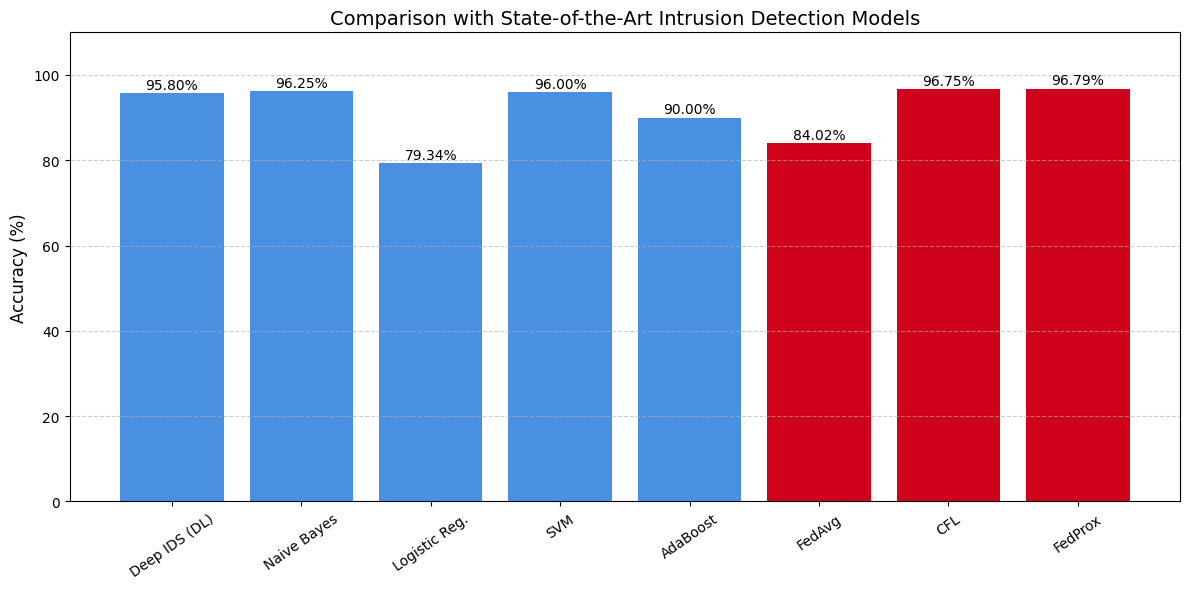

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# SOTA Methods + Our Frameworks
labels = [
    "Deep IDS (DL)",
    "Naive Bayes",
    "Logistic Reg.",
    "SVM",
    "AdaBoost",
    "FedAvg",
    "CFL",
    "FedProx"
]

accuracy = [
    95.80,   # DL IDS
    96.25,   # NB
    79.34,   # LR
    96.00,   # SVM
    90.00,   # AdaBoost
    84.02,   # FedAvg
    96.75,   # CFL
    96.79    # FedProx
]

# Color scheme: SOTA methods (blue), our FL frameworks (red)
colors = [
    "#4A90E2", "#4A90E2", "#4A90E2", "#4A90E2", "#4A90E2",
    "#D0021B", "#D0021B", "#D0021B"
]

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, accuracy, color=colors)

plt.xticks(rotation=35, fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison with State-of-the-Art Intrusion Detection Models", fontsize=14)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add accuracy labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha='center',
        fontsize=10
    )

plt.tight_layout()
plt.savefig("sota_comparison.png", dpi=400)
plt.show()


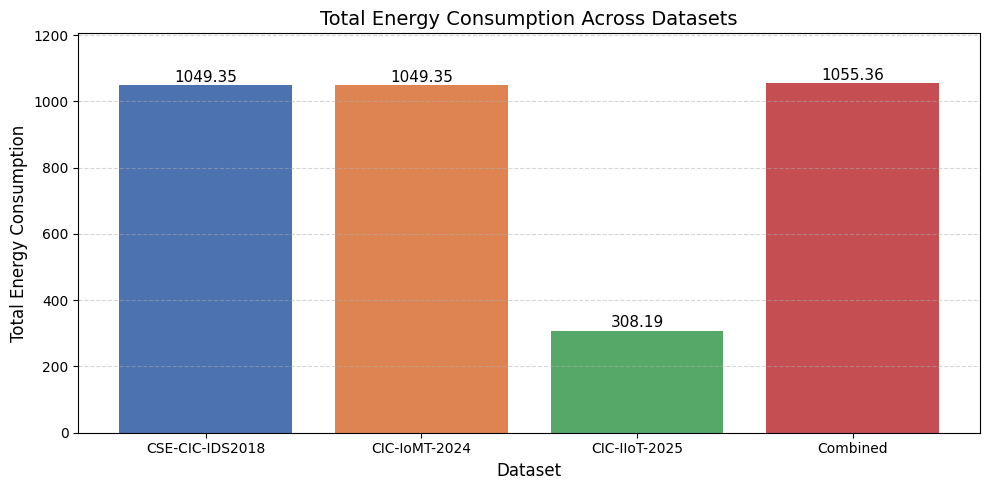

In [5]:
import matplotlib.pyplot as plt

# ---------------------------------------
# Energy values from your simulation
# ---------------------------------------
datasets = ["CSE-CIC-IDS2018", "CIC-IoMT-2024", "CIC-IIoT-2025", "Combined"]
total_energy = [1049.35, 1049.35, 308.19, 1055.36]

# ---------------------------------------
# Plot Styling
# ---------------------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(datasets, total_energy, color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])

# Add energy values on top of bars
for bar, energy in zip(bars, total_energy):
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 10,
             f"{energy:.2f}", ha="center", fontsize=11)

plt.ylabel("Total Energy Consumption", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.title("Total Energy Consumption Across Datasets", fontsize=14)
plt.ylim(0, max(total_energy) + 150)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# ---------------------------------------
# Save the figure
# ---------------------------------------
plt.tight_layout()
plt.savefig("energy_total_across_datasets.png", dpi=400)
plt.show()


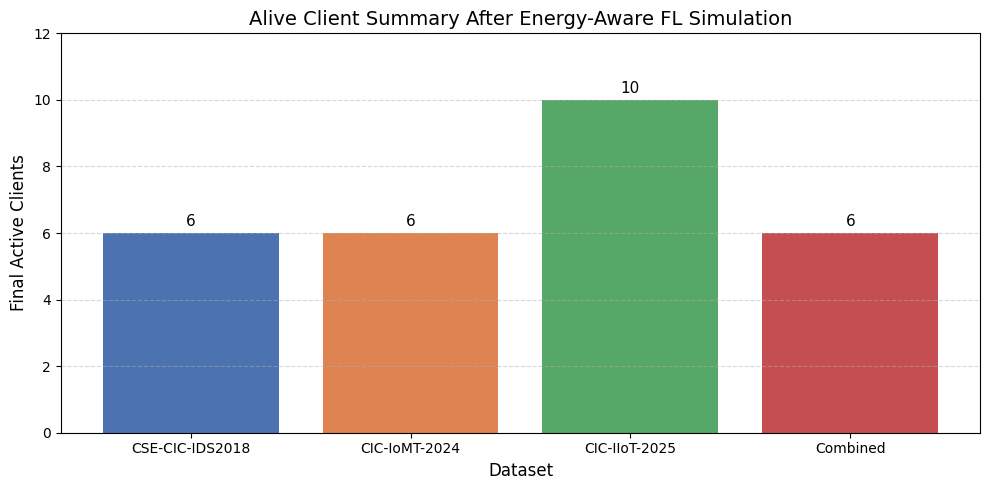

In [6]:
import matplotlib.pyplot as plt

# ---------------------------------------
# Alive client count from your simulation
# ---------------------------------------
datasets = ["CSE-CIC-IDS2018", "CIC-IoMT-2024", "CIC-IIoT-2025", "Combined"]
alive_clients = [6, 6, 10, 6]

# ---------------------------------------
# Plot Styling
# ---------------------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(datasets, alive_clients,
               color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])

# Add value labels above bars
for bar, val in zip(bars, alive_clients):
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.2,
             f"{val}", ha="center", fontsize=11)

plt.ylabel("Final Active Clients", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.title("Alive Client Summary After Energy-Aware FL Simulation", fontsize=14)
plt.ylim(0, max(alive_clients) + 2)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# ---------------------------------------
# Save Figure
# ---------------------------------------
plt.tight_layout()
plt.savefig("alive_clients_summary.png", dpi=400)
plt.show()
